In [ ]:
# Spotify Music Data Analysis Project

## Objective
#To explore which audio features and genres are associated with track popularity on Spotify using exploratory data analysis in Python.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset_folder")

In [5]:
import os
os.listdir("dataset_folder")

['readme.md', 'spotify_songs.csv']

In [ ]:
## Dataset Overview

#The dataset contains Spotify track information including:
#- Audio features (danceability, energy, tempo, etc.)
#- Genre and playlist data
#- Track popularity scores

In [7]:
df = pd.read_csv("dataset_folder/spotify_songs.csv")
df.head()


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [8]:
df.columns

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [11]:
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [12]:
## Introduction
#The goal of this analysis is to identify patterns in Spotify song features and determine what factors may influence track popularity.
#We analyze features such as danceability, energy, tempo, and genre to uncover meaningful insights.#What genres are most common?

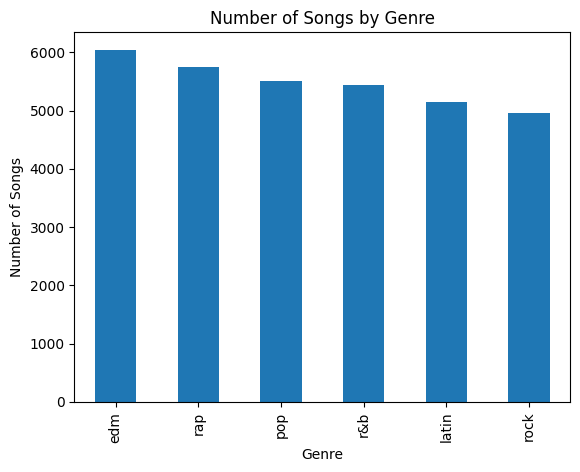

In [13]:
genre_counts = df['playlist_genre'].value_counts()

genre_counts.plot(kind='bar')

plt.xlabel("Genre")
plt.ylabel("Number of Songs")
plt.title("Number of Songs by Genre")

plt.show()

In [ ]:
### Insight: Genre Distribution

#This chart shows how songs are distributed across different genres in the dataset. Some genres appear much more frequently than others, which reflects how playlists are curated on streaming platforms. However, higher frequency does not necessarily mean higher popularity.

In [14]:
#Pop and rap playlists contained the largest number of songs in the dataset, suggesting these genres dominate curated Spotify playlists

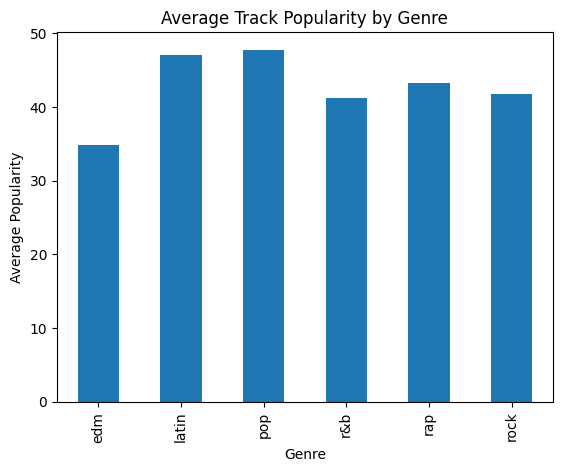

In [15]:
#here I want to go more specific and see what genre is most popular
avg_popularity = df.groupby('playlist_genre')['track_popularity'].mean()

avg_popularity.plot(kind='bar')

plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.title("Average Track Popularity by Genre")

plt.show()

In [16]:
#Now, I am going to go more opinions based - does the beat (how well you can dance to it) affect the popularity?

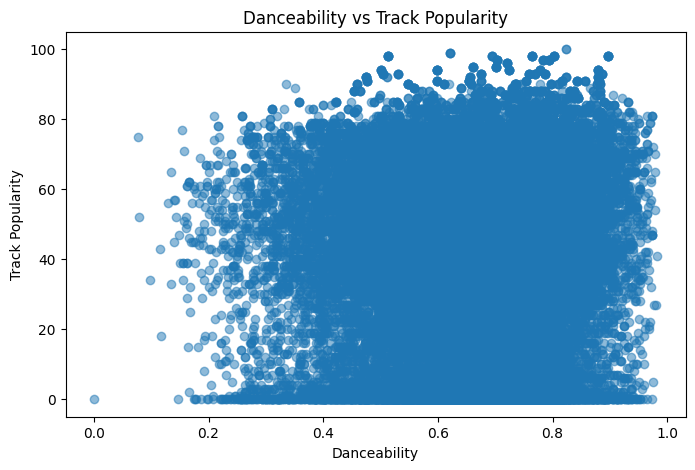

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(df['danceability'], df['track_popularity'], alpha=0.5)

plt.xlabel("Danceability")
plt.ylabel("Track Popularity")
plt.title("Danceability vs Track Popularity")

plt.show()

In [ ]:
### Insight: Danceability vs Popularity

#This plot explores whether more danceable songs tend to be more popular. The relationship appears weak to moderate, suggesting that while danceability may contribute to a song’s success, it is not the sole factor influencing popularity.

In [ ]:
#Generally, there tends to be a correlation between higher danceability and higher song popularity

In [20]:
correlation = df[['danceability', 'energy', 'valence', 'tempo', 'track_popularity']].corr()

correlation

,danceability,energy,valence,tempo,track_popularity
danceability,1.000000,-0.086073,0.330523,-0.184084,0.064748
energy,-0.086073,1.000000,0.151103,0.149951,-0.109112
valence,0.330523,0.151103,1.000000,-0.025732,0.033231
tempo,-0.184084,0.149951,-0.025732,1.000000,-0.005378
track_popularity,0.064748,-0.109112,0.033231,-0.005378,1.000000


In [22]:
## Correlation Analysis
#We now examine relationships between numerical audio features using a correlation heatmap.

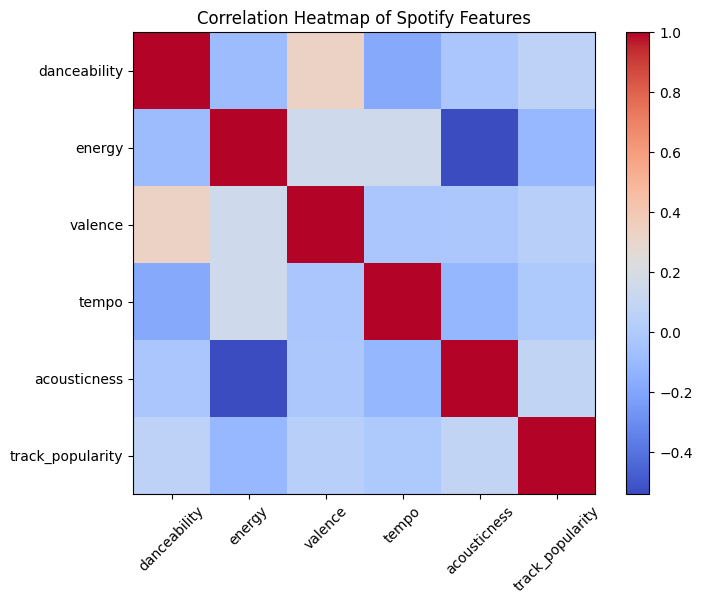

In [31]:
corr_matrix = df[['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'track_popularity']].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.colorbar()
plt.title("Correlation Heatmap of Spotify Features")

plt.show()

In [ ]:
#Tempo vs Popularity


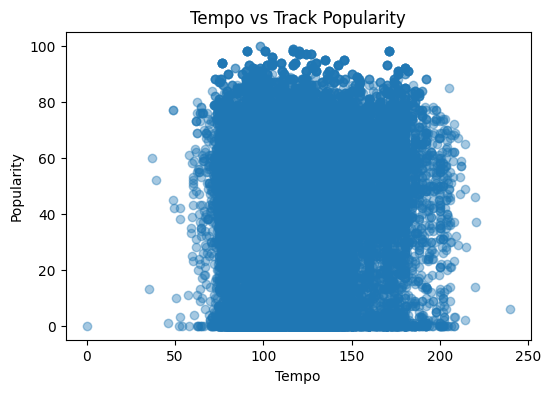

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(df['tempo'], df['track_popularity'], alpha=0.4)

plt.xlabel("Tempo")
plt.ylabel("Popularity")
plt.title("Tempo vs Track Popularity")
plt.show()

In [ ]:
### Insight: Tempo vs Popularity

#The data shows a weak positive relationship, suggesting that song speed alone is not a strong predictor of a track's success.

In [25]:
#Energy vs danceability

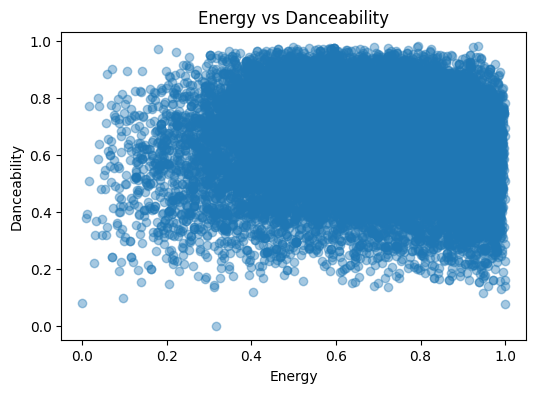

In [26]:
plt.figure(figsize=(6,4))
plt.scatter(df['energy'], df['danceability'], alpha=0.4)

plt.xlabel("Energy")
plt.ylabel("Danceability")
plt.title("Energy vs Danceability")
plt.show()

In [ ]:
### Insight: Energy vs Danceability

#This chart compares two audio features: energy and danceability. There appears to be some relationship between the two, which makes sense since more energetic songs are often designed to be more dance-friendly.

In [27]:
#Genre Preformance

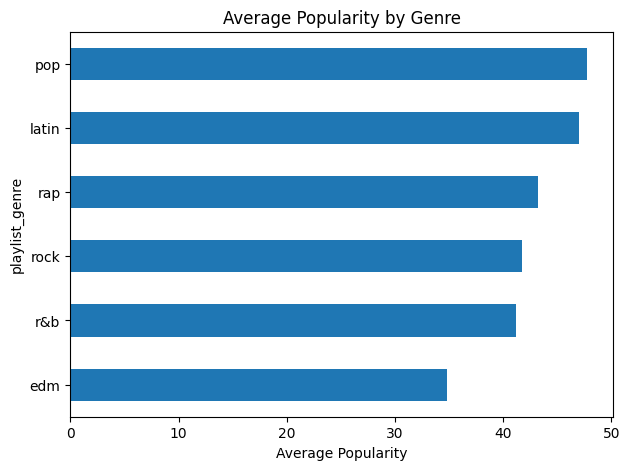

In [28]:
genre_popularity = df.groupby('playlist_genre')['track_popularity'].mean().sort_values()

genre_popularity.plot(kind='barh', figsize=(7,5))

plt.xlabel("Average Popularity")
plt.title("Average Popularity by Genre")
plt.show()

In [ ]:
### Insight: Genre Performance

#This chart compares the average popularity across genres. Some genres tend to perform better on average than others, suggesting that genre has a measurable influence on average track popularity.

In [30]:
top_songs = df.sort_values('track_popularity', ascending=False).head(10)

top_songs[['track_name', 'track_artist', 'track_popularity']]

,track_name,track_artist,track_popularity
20091,Dance Monkey,Tones and I,100
1551,Dance Monkey,Tones and I,100
21468,ROXANNE,Arizona Zervas,99
20092,ROXANNE,Arizona Zervas,99
23104,ROXANNE,Arizona Zervas,99
30202,ROXANNE,Arizona Zervas,99
9018,The Box,Roddy Ricch,98
1301,Circles,Post Malone,98
18308,Memories,Maroon 5,98
18307,Blinding Lights,The Weeknd,98


In [ ]:
## Key Insights Summary

#- Genre distribution is uneven, with some genres dominating playlist counts.
#- Danceability shows a weak positive relationship with popularity.
#- Energy and danceability are moderately related to each other.
#- Tempo does not significantly impact track popularity.
#- No single audio feature strongly determines popularity.

In [ ]:
## Conclusion

#This analysis explored Spotify song characteristics and their relationship with popularity.

#Key findings:
#- Genre has noticeable variation in average popularity.
#- Audio features such as energy and danceability show weak to moderate relationships with popularity.
#- No single feature strongly determines success on its own.

#Overall, music popularity appears to be influenced by a combination of factors rather than one dominant feature.

In [ ]:
## Limitations

#This analysis is based only on correlation and exploratory visualizations. It does not establish causation. Additionally, Spotify popularity may be influenced by external factors such as marketing, artist popularity, and trends that are not included in this dataset.